## OpenAI API 키 발급 및 설정

1. OpenAI API 키 발급

- [OpenAI API 키 발급방법](https://wikidocs.net/233342) 글을 참고해 주세요.

1. `.env` 파일 설정

- 프로젝트 루트 디렉토리에 `.env` 파일을 생성합니다.
- 파일에 API 키를 다음 형식으로 저장합니다:
  `OPENAI_API_KEY` 에 발급받은 API KEY 를 입력합니다.

- `.env` 파일에 발급한 API KEY 를 입력합니다.


In [ ]:
# LangChain 업데이트
# !pip install -r https://raw.githubusercontent.com/teddylee777/langchain-kr/main/requirements.txt

In [1]:
# API KEY를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API KEY 정보로드
load_dotenv()

True

API Key 가 잘 설정되었는지 확인합니다.


In [ ]:
import os

print(f"[API KEY]\n{os.environ['OPENAI_API_KEY'][:-15]}" + "*" * 15)

설치된 LangChain 버전을 확인합니다.

In [3]:
from importlib.metadata import version

print("[LangChain 관련 패키지 버전]")
for package_name in [
    "langchain",
    "langchain-core",
    "langchain-experimental",
    "langchain-community",
    "langchain-openai",
    "langchain-teddynote",
    "langchain-huggingface",
    "langchain-google-genai",
    "langchain-anthropic",
    "langchain-cohere",
    "langchain-chroma",
    "langchain-elasticsearch",
    "langchain-upstage",
    "langchain-cohere",
    "langchain-milvus",
    "langchain-text-splitters",
]:
    try:
        package_version = version(package_name)
        print(f"{package_name}: {package_version}")
    except ImportError:
        print(f"{package_name}: 설치되지 않음")

[LangChain 관련 패키지 버전]
langchain: 0.3.21
langchain-core: 0.3.46
langchain-experimental: 0.3.4
langchain-community: 0.3.20
langchain-openai: 0.3.9
langchain-teddynote: 0.3.44
langchain-huggingface: 0.1.2
langchain-google-genai: 2.1.0
langchain-anthropic: 0.3.10
langchain-cohere: 0.4.3
langchain-chroma: 0.2.2
langchain-elasticsearch: 0.3.2
langchain-upstage: 설치되지 않음
langchain-cohere: 0.4.3
langchain-milvus: 0.1.8
langchain-text-splitters: 0.3.7


# LangSmith 추적 설정

In [4]:
# 직접 추적 설정을 바꾸고 싶을 때 사용
# import os
#
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
# os.environ["LANGCHAIN_PROJECT"] = "LangChain 프로젝트명"
# os.environ["LANGCHAIN_API_KEY"] = "LangChain API KEY 입력"

In [5]:
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("Langchain-Note") # 나의 프로젝트명

LangSmith 추적을 시작합니다.
[프로젝트명]
Langchain-Note


In [6]:
# 추적을 끄는 방법 - set_enable=False 로 지정.
# logging.langsmith("랭체인 튜토리얼 프로젝트", set_enable=False)

# OpenAI API 사용하기(GPT4-4o 멀티모달)

### ChatOpenAI() 함수로 LLM 객체 생성
**옵션으로 지정가능한 파라미터**

`temperature`: 모델의 창의성. 값은 0과 2 사이에서 선택한다.

0.8과 같은 높은 값은 출력을 더 무작위하게 만들고, 0.2와 같은 낮은 값은 출력을 더 집중되고 결정론적으로 만든다.

`max_tokens`: 채팅 완성에서 생성할 토큰의 최대 개수.

`model_name`: 적용 가능한 모델 리스트
- gpt-3.5-turbo
- gpt-4-turbo
- gpt-4o

In [7]:
from langchain_openai import ChatOpenAI

# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    model_name="gpt-4o",  # 모델명
)

# 질의내용
question = "세종대왕은 누구인가요?"

# 질의
response = llm.invoke(question)

print(f"[답변]: {response}")

C:\projects\PycharmProjects\JupyterProject\LangchainNote\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.9) doesn't match a supported version!
  warnings.warn(


[답변]: content='세종대왕은 조선의 제4대 왕으로, 한국 역사에서 가장 존경받는 군주 중 한 명입니다. 그는 1397년에 태어나 1418년부터 1450년까지 재위했습니다. 세종대왕은 특히 한글 창제와 관련하여 유명합니다. 그는 백성들이 쉽게 읽고 쓸 수 있는 문자를 만들기 위해 훈민정음을 창제하였으며, 이는 오늘날의 한글로 발전했습니다.\n\n세종대왕은 또한 과학, 기술, 문화, 예술 등 여러 분야에서 많은 업적을 남겼습니다. 그는 천문학, 의학, 농업 등 다양한 분야의 연구를 장려하고, 측우기와 같은 과학 기구를 개발하도록 지원했습니다. 그의 통치 아래 조선은 정치적 안정과 문화적 번영을 누렸습니다. 세종대왕의 업적은 오늘날까지도 한국 사회에 큰 영향을 미치고 있습니다.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 207, 'prompt_tokens': 16, 'total_tokens': 223, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6cd46c5087', 'id': 'chatcmpl-E3y7GZ86SveChhKIVs2IBnO63rWh9', 'finish_reason': 'stop', 'logprobs': None} id='run-f305c64c-2c23-4f26-a26f-b86f7b450f03-0' usage_metadata={'input_tokens': 16, 'output_tokens': 20

In [8]:
response.content

'세종대왕은 조선의 제4대 왕으로, 한국 역사에서 가장 존경받는 군주 중 한 명입니다. 그는 1397년에 태어나 1418년부터 1450년까지 재위했습니다. 세종대왕은 특히 한글 창제와 관련하여 유명합니다. 그는 백성들이 쉽게 읽고 쓸 수 있는 문자를 만들기 위해 훈민정음을 창제하였으며, 이는 오늘날의 한글로 발전했습니다.\n\n세종대왕은 또한 과학, 기술, 문화, 예술 등 여러 분야에서 많은 업적을 남겼습니다. 그는 천문학, 의학, 농업 등 다양한 분야의 연구를 장려하고, 측우기와 같은 과학 기구를 개발하도록 지원했습니다. 그의 통치 아래 조선은 정치적 안정과 문화적 번영을 누렸습니다. 세종대왕의 업적은 오늘날까지도 한국 사회에 큰 영향을 미치고 있습니다.'

In [9]:
response.response_metadata

{'token_usage': {'completion_tokens': 207,
  'prompt_tokens': 16,
  'total_tokens': 223,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_6cd46c5087',
 'id': 'chatcmpl-E3y7GZ86SveChhKIVs2IBnO63rWh9',
 'finish_reason': 'stop',
 'logprobs': None}

## LogProb 활성화
주어진 텍스트에 대한 모델의 **토큰 확률의 로그 값**

- **토큰**: 문장을 구성하는 개별 단어나 문자 등의 요소.
- **토큰 확률**: 모델이 그 토큰을 예측할 확률

In [10]:
# 객체 생성
llm_with_logprob = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    max_tokens=2048,  # 최대 토큰수
    model_name="gpt-3.5-turbo",  # 모델명
).bind(logprobs=True)

In [11]:
# 질의내용
question = "세종대왕은 누구인가요?"

# 질의
response = llm_with_logprob.invoke(question)

In [12]:
response

AIMessage(content='세종대왕은 조선시대 4대 왕 중 한 명으로, 조선시대의 제4대 군주이자 문신이다. 1418년에 태어나 1450년에 왕위에 오르고, 1455년에 즉위하여 29년 동안 통치한 조선시대의 대왕이다. 그는 한글을 창제하고 학문과 문화를 발전시키는 데 큰 기여를 한 것으로 유명하다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 143, 'prompt_tokens': 23, 'total_tokens': 166, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E3yH9Fxr4WKgAohesJKiCFahKbTu7', 'finish_reason': 'stop', 'logprobs': {'content': [{'token': '세', 'bytes': [236, 132, 184], 'logprob': -0.05531608, 'top_logprobs': []}, {'token': '\\xec', 'bytes': [236], 'logprob': -7.648396e-05, 'top_logprobs': []}, {'token': '\\xa2', 'bytes': [162], 'logprob': 0.0, 'top_logprobs': []}, {'token': '\\x85', 'bytes': [133], 'logprob': 0.0, 'top_logprobs': []}, {'tok

In [15]:
response.response_metadata

{'token_usage': {'completion_tokens': 143,
  'prompt_tokens': 23,
  'total_tokens': 166,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-3.5-turbo-0125',
 'system_fingerprint': None,
 'id': 'chatcmpl-E3yH9Fxr4WKgAohesJKiCFahKbTu7',
 'finish_reason': 'stop',
 'logprobs': {'content': [{'token': '세',
    'bytes': [236, 132, 184],
    'logprob': -0.05531608,
    'top_logprobs': []},
   {'token': '\\xec',
    'bytes': [236],
    'logprob': -7.648396e-05,
    'top_logprobs': []},
   {'token': '\\xa2', 'bytes': [162], 'logprob': 0.0, 'top_logprobs': []},
   {'token': '\\x85', 'bytes': [133], 'logprob': 0.0, 'top_logprobs': []},
   {'token': '대',
    'bytes': [235, 140, 128],
    'logprob': -0.00016444526,
    'top_logprobs': []},
   {'token': '\\xec\\x99',
    'bytes': [236, 153],
    'logprob': -1.624056

## 스트리밍 출력
스트리밍 옵션은 질의에 대한 답변을 실시간으로 받을 때 유용하다.

In [23]:
# 스트림 방식으로 질의
answer = llm.stream("대한민국의 아름다운 역사유적 10곳과 주소를 알려주세요.")

In [24]:
# 스트리밍 방식으로 각 토큰을 실시간 출력한다.
for token in answer:
    print(token.content, end="", flush=True)

대한민국에는 아름다운 역사 유적지가 많이 있습니다. 아래는 그 중 10곳과 그 주소입니다.

1. **경복궁**
   - 주소: 서울특별시 종로구 사직로 161

2. **창덕궁**
   - 주소: 서울특별시 종로구 율곡로 99

3. **불국사**
   - 주소: 경상북도 경주시 불국로 385

4. **석굴암**
   - 주소: 경상북도 경주시 불국로 873-243

5. **수원 화성**
   - 주소: 경기도 수원시 팔달구 정조로 825

6. **종묘**
   - 주소: 서울특별시 종로구 종로 157

7. **해인사**
   - 주소: 경상남도 합천군 가야면 해인사길 122

8. **경주 대릉원**
   - 주소: 경상북도 경주시 계림로 9

9. **남한산성**
   - 주소: 경기도 광주시 남한산성면 산성리

10. **안동 하회마을**
    - 주소: 경상북도 안동시 풍천면 하회종가길 40

이 유적지들은 한국의 역사와 문화를 깊이 있게 이해할 수 있는 장소들입니다. 방문 시 각 장소의 운영 시간과 입장료 등을 미리 확인하는 것이 좋습니다.

In [25]:
from langchain_teddynote.messages import stream_response

# 스트림 방식으로 질의하고 스트리밍 답변의 결과를 받는다.
answer = llm.stream("대한민국 서울의 아름다운 관광지 10곳과 주소를 알려주세요.")
stream_response(answer)

서울은 다양한 매력을 가진 도시로, 많은 아름다운 관광지가 있습니다. 다음은 서울의 대표적인 관광지 10곳과 그 주소입니다.

1. **경복궁**
   - 주소: 서울특별시 종로구 사직로 161

2. **창덕궁**
   - 주소: 서울특별시 종로구 율곡로 99

3. **북촌 한옥마을**
   - 주소: 서울특별시 종로구 계동길 37

4. **남산서울타워 (N서울타워)**
   - 주소: 서울특별시 용산구 남산공원길 105

5. **명동 쇼핑거리**
   - 주소: 서울특별시 중구 명동길 8 일대

6. **인사동 거리**
   - 주소: 서울특별시 종로구 인사동길 62 일대

7. **동대문디자인플라자 (DDP)**
   - 주소: 서울특별시 중구 을지로 281

8. **롯데월드**
   - 주소: 서울특별시 송파구 올림픽로 240

9. **한강공원**
   - 주소: 서울특별시 영등포구 여의동로 330 (여의도 한강공원 기준)

10. **서울숲**
    - 주소: 서울특별시 성동구 뚝섬로 273

이곳들은 서울의 역사와 현대적인 매력을 동시에 느낄 수 있는 장소들로, 방문객들에게 다양한 경험을 제공합니다.

## 멀티모달 모델(이미지 인식)

**멀티모달**: 여러가지 형태(유형)의 정보(모달)를 통합하여 처리하는 기술이나 접근 방식.

**데이터 유형**
- 텍스트
- 이미지
- 오디오
- 비디오

`gpt-4o`나 `gpt-4-turbo` 모델은 이미지 인식(Vision) 기능이 추가되어 있다.

In [26]:
from langchain_teddynote.models import MultiModal
from langchain_teddynote.messages import stream_response

# 객체 생성
llm = ChatOpenAI(
    temperature=0.1,  # 창의성 (0.0 ~ 2.0)
    max_tokens=2048,  # 최대 토큰수
    model_name="gpt-4o",  # 모델명
)

# 멀티모달 객체 생성
multimodal_llm = MultiModal(llm)


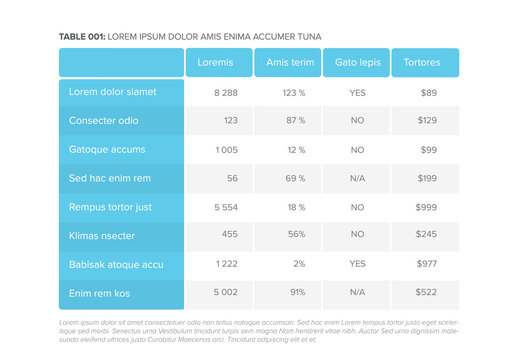

The image is a table with a header labeled "TABLE 001: LOREM IPSUM DOLOR AMIS ENIMA ACCUMER TUNA." It consists of five columns with the following headings:

1. **Loremis**: Contains numerical values.
2. **Amis terim**: Contains percentages.
3. **Gāto lepis**: Contains "YES," "NO," or "N/A."
4. **Tortores**: Contains currency values in dollars.

Each row under these columns has different entries, likely representing different data points or categories. The first column contains placeholder text, typical of "Lorem Ipsum," which is used as filler text in design.

Below the table, there is additional "Lorem Ipsum" text, serving as placeholder content, possibly for a caption or explanation related to the table. The design uses a mix of blue and white for visual distinction between the header and the data rows.

In [27]:
# 샘플 이미지 주소(웹사이트에서 가져와 바로 인식)
IMAGE_URL = "https://t3.ftcdn.net/jpg/03/77/33/96/360_F_377339633_Rtv9I77sSmSNcev8bEcnVxTHrXB4nRJ5.jpg"

# 이미지 파일로 질의
answer = multimodal_llm.stream(IMAGE_URL)

# 스트리밍 방식으로 각 토큰을 실시간 출력
stream_response(answer)


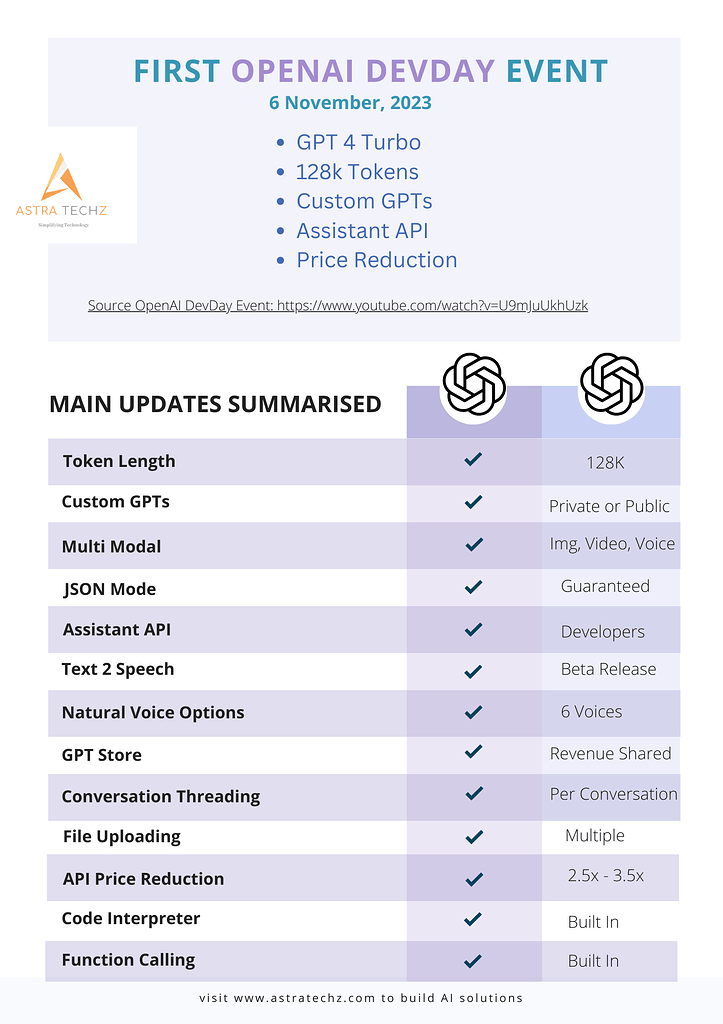

The image is an infographic summarizing the key updates from the "First OpenAI DevDay Event" held on November 6, 2023. It highlights several new features and improvements related to OpenAI's offerings. Here's a detailed breakdown:

### Event Highlights
- **Date**: November 6, 2023
- **Key Announcements**:
  - **GPT 4 Turbo**: An enhanced version of GPT-4.
  - **128k Tokens**: Increased token limit for processing larger inputs.
  - **Custom GPTs**: Ability to create personalized GPT models.
  - **Assistant API**: New API for developers to integrate AI assistants.
  - **Price Reduction**: Lower costs for using OpenAI's services.

### Main Updates Summarized
- **Token Length**: Expanded to 128K tokens.
- **Custom GPTs**: Options for private or public deployment.
- **Multi Modal**: Supports images, videos, and voice inputs.
- **JSON Mode**: Guaranteed JSON output format.
- **Assistant API**: Available for developers.
- **Text to Speech**: Beta release of text-to-speech capabilities.
- **Na

In [28]:
# 로컬 PC 에 저장되어 있는 이미지의 경로 입력
IMAGE_PATH_FROM_FILE = "images/sample-image.png"

# 이미지 파일로 질의(스트림 방식)
answer = multimodal_llm.stream(IMAGE_PATH_FROM_FILE)

# 토큰 실시간 출력
stream_response(answer)

## System, User 프롬프트 수정

In [29]:
# 프롬프트 생성
system_prompt = """당신은 표(재무제표) 를 해석하는 금융 AI 어시스턴트 입니다.
당신의 임무는 주어진 테이블 형식의 재무제표를 바탕으로 흥미로운 사실을 정리하여 친절하게 답변하는 것입니다."""

user_prompt = """당신에게 주어진 표는 회사의 재무제표 입니다. 흥미로운 사실을 정리하여 답변하세요."""

# 멀티모달 객체 생성
multimodal_llm_with_prompt = MultiModal(
    llm, system_prompt=system_prompt, user_prompt=user_prompt
)


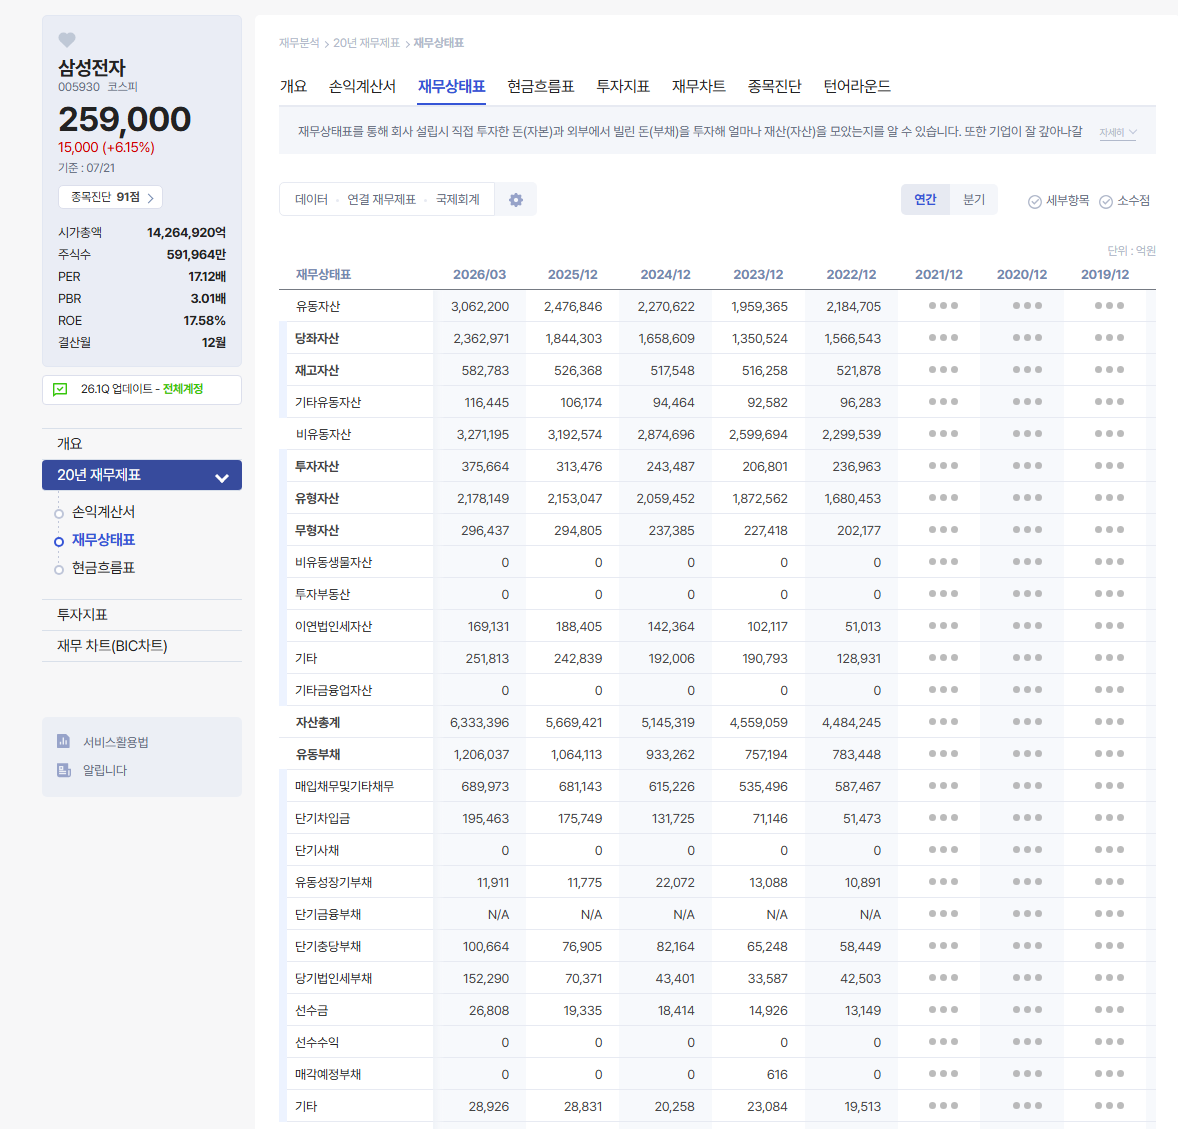

이 재무제표에서 몇 가지 흥미로운 사실을 정리해보겠습니다:

1. **유동자산 증가**: 2020년부터 2023년까지 유동자산이 꾸준히 증가하고 있습니다. 2020년 12월에는 2,184,705억 원이었으나 2023년 12월에는 2,476,846억 원으로 증가했습니다. 이는 회사의 단기적인 재무 유동성이 개선되고 있음을 나타냅니다.

2. **비유동자산의 안정성**: 비유동자산은 2020년부터 2023년까지 큰 변동 없이 안정적으로 유지되고 있습니다. 이는 회사의 장기적인 자산 관리가 안정적임을 시사합니다.

3. **부채의 감소**: 2020년 12월부터 2023년 12월까지 부채총계가 감소하고 있습니다. 2020년 12월에는 1,680,453억 원이었으나 2023년 12월에는 2,059,452억 원으로 증가했지만, 2022년 12월에 비해 감소 추세를 보입니다.

4. **자본의 증가**: 자본총계는 2020년 12월 4,484,245억 원에서 2023년 12월 5,145,319억 원으로 증가했습니다. 이는 회사의 자본이 꾸준히 증가하고 있음을 보여줍니다.

5. **매입채무 및 기타채무의 증가**: 매입채무 및 기타채무가 2020년 12월 587,467억 원에서 2023년 12월 681,143억 원으로 증가했습니다. 이는 회사의 외상 매입이 증가했음을 나타낼 수 있습니다.

이러한 지표들은 회사의 재무 상태가 전반적으로 안정적이며, 자산과 자본이 증가하고 있음을 보여줍니다.

In [31]:
# 로컬 PC 에 저장되어 있는 이미지 경로 입력
IMAGE_PATH_FROM_FILE = "images/img_1.png"

# 이미지 파일로 질의
answer = multimodal_llm_with_prompt.stream(IMAGE_PATH_FROM_FILE)

# 실시간 출력
stream_response(answer)